# Análisis estadístico para detectar patrones y outliers IV 🐍🖥️✍️

## Objetivos académicos

- Mostrar ejemplo de resumen estadístico para el dataset *EverPeak*
- Cargar nuestro reporte a Github

## Analisis de datos de Megaline

---

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos. Vamos analizar por separado los consumos de llamdas, mensajes SMS y Gigabits para entender el comportamiento de los usuarios en cada servicio.



### Descripción de las tarifas

Megaline redondea los segundos a minutos y los megabytes a gigabytes. Para las llamadas, cada llamada individual se redondea: incluso si la llamada duró solo un segundo, se contará como un minuto. Para el tráfico web, las sesiones web individuales no se redondean. En vez de esto, el total del mes se redondea hacia arriba. Si alguien usa 1025 megabytes este mes, se le cobrarán 2 gigabytes.



### Descripción de los datos

**Instrucciones**

*En esta sección haz la descripción general de los datos, cantidad de registros, cantidad de columnas. Discute sobre la calidad de los datos y la necesidad de limpieza. Describe cómo los datos se relacionan entre si*

#### Código de referencia

In [35]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [30]:
sns.set_style('whitegrid')
sns.set_palette('pastel')

In [39]:
megaline_calls = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/megaline_calls.csv')
megaline_internet = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/megaline_internet.csv')
megaline_messages = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/megaline_messages.csv')
megaline_plans = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/megaline_plans.csv')
megaline_users = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/megaline_users.csv')



In [6]:
megaline_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


### Limpieza de datos

**Instrucciones**

*Describe el tratamiento de limpieza para los datos, discute nulos, duplicados, necesidad de preparación para el análisis*

> 💡 Haz las trasformaciones necesarias relativas al consumo, redondeo y transformaciones

#### Código de referencia

In [7]:
megaline_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [40]:
#Limpieza de duplicados
megaline_users.drop_duplicates(inplace=True)

In [41]:
megaline_users.drop(columns=['churn_date'],inplace=True)

In [42]:
#Extraer ciudad y estado
megaline_users['state'] = megaline_users['city'].str.split(',').str[1]
megaline_users['city'] = megaline_users['city'].str.split(',').str[0]

In [24]:
# Extraer año-mes

megaline_messages['message_month_year'] = pd.to_datetime(megaline_messages['message_date'],errors='coerce').dt.strftime("%Y-%m")

### Agrupación por consumo mes-usuario y análisis estadístico

**Instrucciones**

*Agrupa los datos por consumo por mes-usuarios. Analiza la distribución del consumo mes-usuario, describe los estadístico y la forma de la distribución. Determina comportamientos atípicos y discute el tratamiento que le darás*

#### Código de referencia

In [27]:
megaline_messages_by_month_user=megaline_messages.groupby(['message_month_year','user_id'])['user_id'].count().reset_index(name='messages')

In [34]:
megaline_messages_by_month_user['messages'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
messages,1806.0,42.110188,33.122931,1.0,17.0,34.0,59.0,266.0


Text(0.5, 1.0, 'Distribución de envio de mensajes por usuario mensualmente')

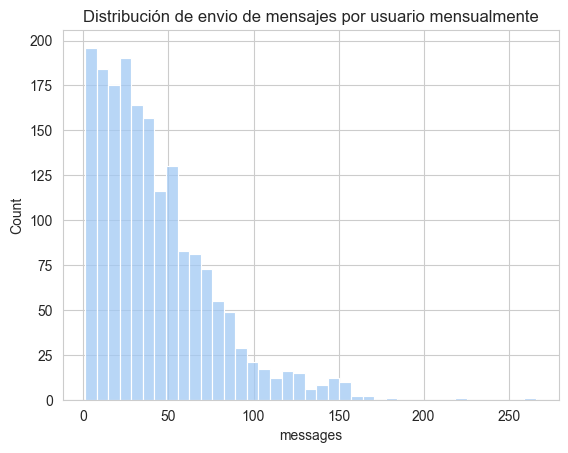

In [32]:
sns.histplot(data=megaline_messages_by_month_user,x='messages')
plt.title('Distribución de envio de mensajes por usuario mensualmente')

Text(0.5, 1.0, 'Distribución de envio de mensajes por usuario mensualmente')

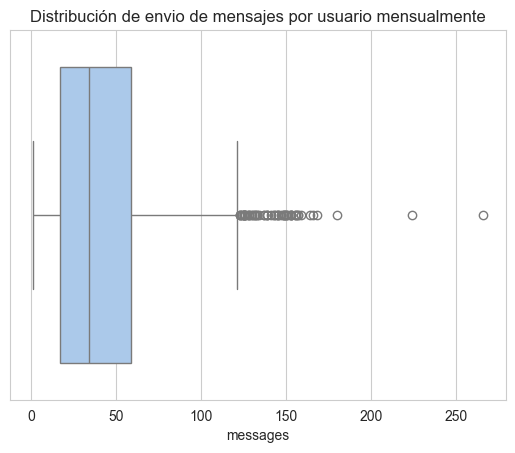

In [33]:
sns.boxplot(data=megaline_messages_by_month_user,x='messages')
plt.title('Distribución de envio de mensajes por usuario mensualmente')

In [ ]:
#Identificación por IQR
def outlier_iqr(x,q1,q3):
    iqr=q3-q1
    return not((q1-1.5*iqr)<x<(q3+1.5*iqr))

q1=megaline_messages_by_month_user['messages'].quantile(0.25)
q3=megaline_messages_by_month_user['messages'].quantile(0.75)
megaline_messages_by_month_user['messages_outlier_iqr']= megaline_messages_by_month_user['order_value'].apply(outlier_iqr,q1=q1,q3=q3)

In [ ]:
megaline_messages_by_month_user['messages_outlier_iqr'].sum()

In [ ]:
# Drop
megaline_messages_by_month_user_drop_outliers= megaline_messages_by_month_user[megaline_messages_by_month_user['messages_outlier_iqr']]

In [37]:
# Winsorize
lower= megaline_messages_by_month_user['messages'].min()
upper= megaline_messages_by_month_user['messages'].quantile(0.99)
megaline_messages_by_month_user['messages_winsorize']=np.clip(megaline_messages_by_month_user['messages'],lower,upper)

### Segmentación de usuarios

## 🚀 Para seguir aprendiendo :

---

- 📚 Vuelve a revisar este notebook y trata resolver por tu cuenta  nuevamente
- 💬 Recuerda que en Discord puedes dejar todos tus comentarios y dudas sobre el contenido del sprint en [`Discord`](https://discord.com/channels/1081207584104656986/1420849538196836472).
    - 📝 Si tienes preguntas sobre tu proyecto, usa el canal [`#project`](https://discord.com/channels/1081207584104656986/1420848813186351134) para recibir ayuda y compartir ideas.
    - 🤝 Aprovecha el espacio de `CoLearning` para aclarar tus dudas junto con otros estudiantes e instructores: [Co-Learning](https://discord.com/channels/1081207584104656986/1197953851391746119).
    - En tus preguntas recuerda etiquetar a `@Dataconsulta` y ubica tu pregunta de acuerdo a `Sprint/Capitulo/Seccion`
- 📅 ¿Necesitas ayuda personalizada? Puedes agendar una sesión `1:1` conmigo aquí: [1:1 Roman Castillo](https://scheduler.zoom.us/roman-castillo/1-1-roman-castillo).

- Por último hazme paro y responde la encuesta al final de la sesión, me sirve para poder ayudarte mejor 

¡Sigue practicando y no dudes en pedir apoyo cuando lo necesites! 💪✨